In [1]:
import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')



In [2]:
from pathlib import Path
import sys
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from src.data_preprocessing import data_split
from utils.evaluate_model import evaluate_model
from src.learning_curve_plot import plot_learning_curve


In [3]:
df = pd.read_csv('../data/processed/processed_data.csv', parse_dates=['Date'])

FEATURE_COLS = [
    'CPI_Change_lag1', 'Rate_Change', 'GDP_Growth_lag2', 'Unemp_Change_lag1',
    'USD_Change', 'VIX_Change', 'Credit_Spread_lag2']

splits_data = data_split(df, FEATURE_COLS)
X_train= splits_data['X_train']
y_train     = splits_data['y_train']
X_test  = splits_data['X_test']
y_test      = splits_data['y_test']
dates_test = splits_data['dates_test']

TARGET = 'SP500_Return'



  Features (7): CPI_Change_lag1, Rate_Change, GDP_Growth_lag2, Unemp_Change_lag1, USD_Change, VIX_Change, Credit_Spread_lag2


In [4]:
print("Building XGBoost DMatrix")

dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=FEATURE_COLS)
dtest = xgb.DMatrix(X_test,  label=y_test,  feature_names=FEATURE_COLS)

print(f"  dtrain : {dtrain.num_row()} rows × {dtrain.num_col()} features")
print(f"  dtest  : {dtest.num_row()} rows × {dtest.num_col()} features")

Building XGBoost DMatrix
  dtrain : 346 rows × 7 features
  dtest  : 69 rows × 7 features


### Model 1

[0]	train-rmse:3.85142	test-rmse:4.88363
[10]	train-rmse:2.51526	test-rmse:4.31733
[20]	train-rmse:1.94068	test-rmse:4.26734
[29]	train-rmse:1.62661	test-rmse:4.26482
  XGBoost Baseline
  Metric                         Train       Test
  ---------------------------------------------
  R²                            0.8412     0.2778
  RMSE (%)                       1.627      4.265
  MAE (%)                        1.214      3.379
  Directional Acc (%)            90.75      68.12


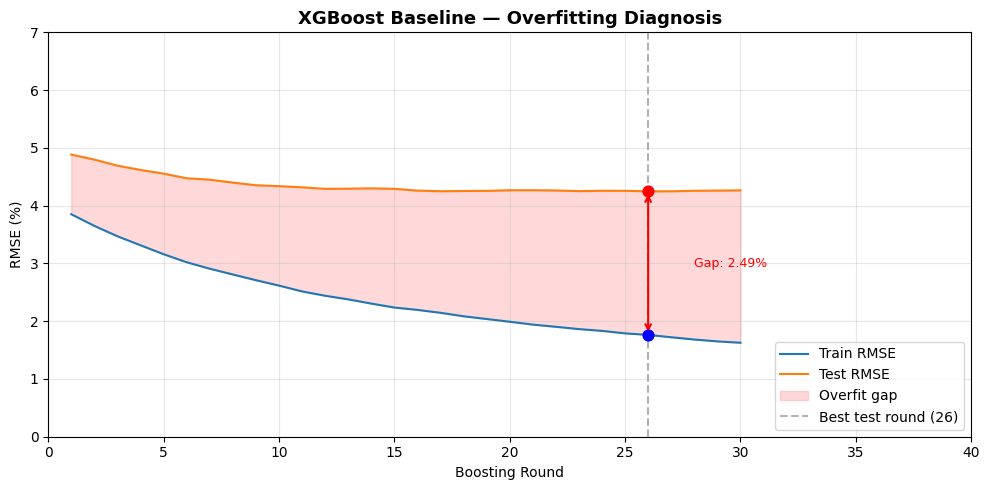

  Best round: 26  |  Train RMSE: 1.7628  |  Test RMSE: 4.2485  |  Gap: 2.4857


In [5]:
baseline_params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "eta": 0.1,              # learning rate 
    "max_depth": 6,          # depth of each tree
}

BASELINE_ROUNDS = 30        # fixed, no early stopping

# Train
evals_baseline = {}
baseline_model = xgb.train(
    params          = baseline_params,
    dtrain          = dtrain,
    num_boost_round = BASELINE_ROUNDS,
    evals           = [(dtrain, 'train'), (dtest, 'test')],
    evals_result    = evals_baseline,
    verbose_eval    = 10,
)

# Predict
y_pred_baseline = baseline_model.predict(dtest)

ev_base = evaluate_model(
        baseline_model, dtrain, y_train,
        dtest, y_test, "XGBoost Baseline"
    )

plot_learning_curve(evals_baseline, model_name="XGBoost Baseline")

### Model 2

[0]	train-rmse:4.06786	test-rmse:5.02671
[50]	train-rmse:3.64333	test-rmse:4.64386
[100]	train-rmse:3.41902	test-rmse:4.46099
[150]	train-rmse:3.26672	test-rmse:4.34361
[200]	train-rmse:3.15711	test-rmse:4.25389
[250]	train-rmse:3.07313	test-rmse:4.19769
[299]	train-rmse:3.00816	test-rmse:4.17115
  XGBoost Optimised
  Metric                         Train       Test
  ---------------------------------------------
  R²                            0.4567     0.3092
  RMSE (%)                       3.008      4.171
  MAE (%)                        2.258      3.275
  Directional Acc (%)            77.75      72.46


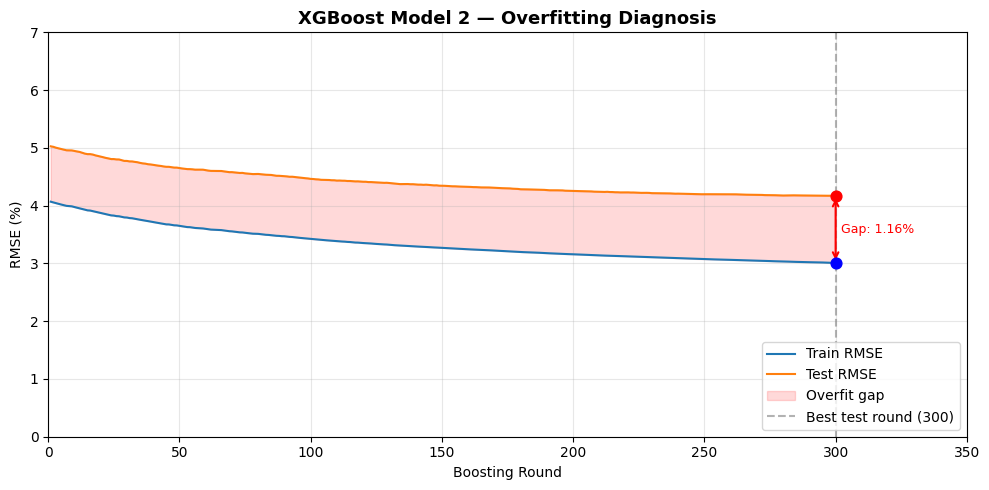

  Best round: 300  |  Train RMSE: 3.0082  |  Test RMSE: 4.1711  |  Gap: 1.1630


In [6]:
better_params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "eta": 0.01,                 # slower learning (default 0.3 is too fast)
    "max_depth": 2,              # smaller trees = less memorization

    "min_child_weight": 10,       # requires more data per leaf
    "subsample": 0.8,            # use 80% rows per tree
    "colsample_bytree": 0.8 ,   # use 80% features per tree
    "gamma": 1,                  # minimum loss reduction to split
}

evals_result2 = {}


model2 = xgb.train(
    params=better_params,
    dtrain=dtrain,
    num_boost_round=300,
    evals=[(dtrain, "train"), (dtest, "test")],
    early_stopping_rounds=50,
    evals_result    = evals_result2,
    verbose_eval=50
)

y_pred_baseline = baseline_model.predict(dtest)

ev_opt = evaluate_model(
        model2, dtrain, y_train,
        dtest, y_test, "XGBoost Optimised"
    )

plot_learning_curve(evals_result2, model_name="XGBoost Model 2")



### Model 3

[0]	train-rmse:4.03686+0.12519	test-rmse:4.02141+0.54856
[100]	train-rmse:2.74411+0.07748	test-rmse:3.37418+0.37625
[163]	train-rmse:2.50144+0.07935	test-rmse:3.38482+0.37932

  CV complete — now training final model on ALL training data...
     Optimal rounds (from CV) : 134
     Best CV RMSE             : 3.3644% ± 0.3758%
     Rounds saved by early stop: 1866

[0]	train-rmse:4.06786	test-rmse:5.02671
[50]	train-rmse:3.64333	test-rmse:4.64386
[100]	train-rmse:3.41902	test-rmse:4.46099
[133]	train-rmse:3.30815	test-rmse:4.37296

  Model trained on ALL training data with 134 rounds.
     Trees built : 134
     Best CV RMSE : 3.3644% ± 0.3758%
  XGBoost CV-Tuned
  Metric                         Train       Test
  ---------------------------------------------
  R²                            0.3430     0.2408
  RMSE (%)                       3.308      4.373
  MAE (%)                        2.470      3.505
  Directional Acc (%)            77.17      72.46


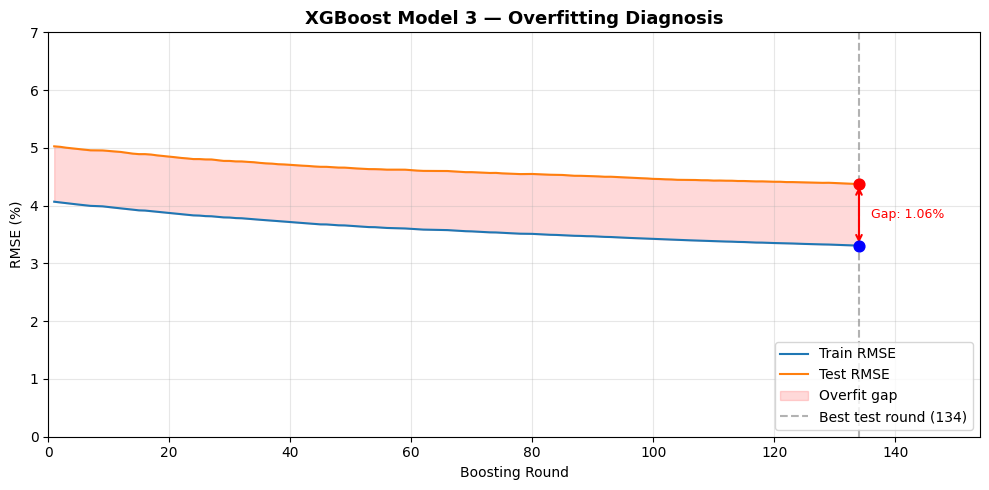

  Best round: 134  |  Train RMSE: 3.3081  |  Test RMSE: 4.3730  |  Gap: 1.0648


In [7]:
opt_params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "eta": 0.03,                 # slower learning (default 0.3 is too fast)
    "max_depth": 3,              # smaller trees = less memorization

    "min_child_weight": 10,       # requires more data per leaf
    "subsample": 0.8,            # use 80% rows per tree
    "colsample_bytree": 0.8 ,   # use 80% features per tree

}


N_FOLDS      = 5      # 5-fold CV for validation
BOOST_ROUNDS = 2000    # max rounds for CV (early stopping will cut this short)

cv_results = xgb.cv(
    params            = opt_params,
    dtrain            = dtrain,
    num_boost_round   = BOOST_ROUNDS,
    nfold             = N_FOLDS,
    metrics           = 'rmse',
    early_stopping_rounds = 30,
    verbose_eval      = 100,
)

# Extract optimal number of rounds from CV results
best_round = len(cv_results)                          # rounds before early stop triggered
best_score = cv_results['test-rmse-mean'].min()       # best mean CV RMSE
best_std   = cv_results.loc[cv_results['test-rmse-mean'].idxmin(), 'test-rmse-std']

print(f"\n  CV complete — now training final model on ALL training data...")
print(f"     Optimal rounds (from CV) : {best_round}")
print(f"     Best CV RMSE             : {best_score:.4f}% ± {best_std:.4f}%")
print(f"     Rounds saved by early stop: {BOOST_ROUNDS - best_round}\n")

# Store evaluation history for learning curves
evals_result3 = {}

# Train final model on the FULL training set using the optimal round count
model3 = xgb.train(
    params          = better_params,
    dtrain          = dtrain,
    num_boost_round = best_round,        # use CV-tuned round count, no early stopping needed
    evals           = [(dtrain, 'train'), (dtest, 'test')],
    evals_result    = evals_result3,
    verbose_eval    = 50,
)

print(f"\n  Model trained on ALL training data with {best_round} rounds.")
print(f"     Trees built : {best_round}")
print(f"     Best CV RMSE : {best_score:.4f}% ± {best_std:.4f}%")



ev_tune = evaluate_model(
        model3, dtrain, y_train,
        dtest, y_test, "XGBoost CV-Tuned"
    )

plot_learning_curve(evals_result3, model_name="XGBoost Model 3")



### Feature Importance

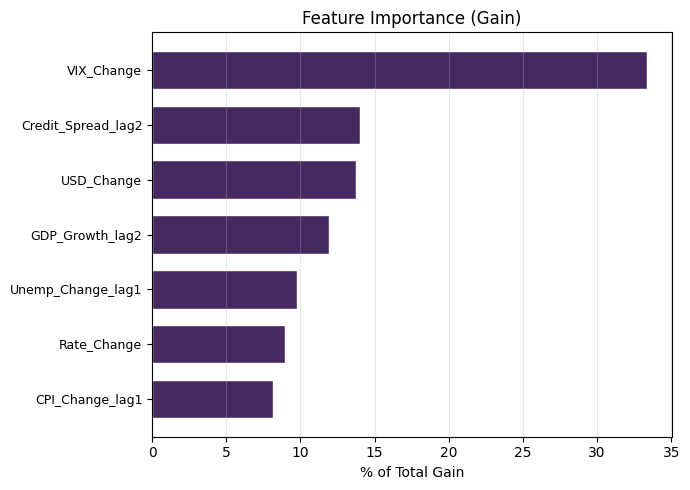

In [8]:
importance_gain   = model2.get_score(importance_type='gain')
importance_weight = model2.get_score(importance_type='weight')

imp_df = pd.DataFrame({
    'Feature'  : list(importance_gain.keys()),
    'Gain'     : list(importance_gain.values()),
    'Weight'   : [importance_weight.get(f, 0) for f in importance_gain.keys()]
}).sort_values('Gain', ascending=True)

# Normalise to 0-100 for readability
imp_df['Gain_pct']   = imp_df['Gain']   / imp_df['Gain'].sum()   * 100
imp_df['Weight_pct'] = imp_df['Weight'] / imp_df['Weight'].sum() * 100


# Features not used at all
unused = [f for f in FEATURE_COLS if f not in importance_gain]
if unused:
    print(f"\n  Features NOT used in any split: {unused}")
    print(f"These contribute nothing. Consider dropping them in above step.")


def plot_feature_importance(imp_df):
    fig, ax = plt.subplots(figsize=(7, 5))
    imp_plot = imp_df.sort_values('Gain_pct')

    ax.barh(range(len(imp_plot)), imp_plot['Gain_pct'],
            color="#472962", edgecolor='white', height=0.7)
    ax.set_yticks(range(len(imp_plot)))
    ax.set_yticklabels(imp_plot['Feature'], fontsize=9)
    ax.set_title('Feature Importance (Gain)')
    ax.set_xlabel('% of Total Gain')
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

plot_feature_importance(imp_df)




**Plotting results**


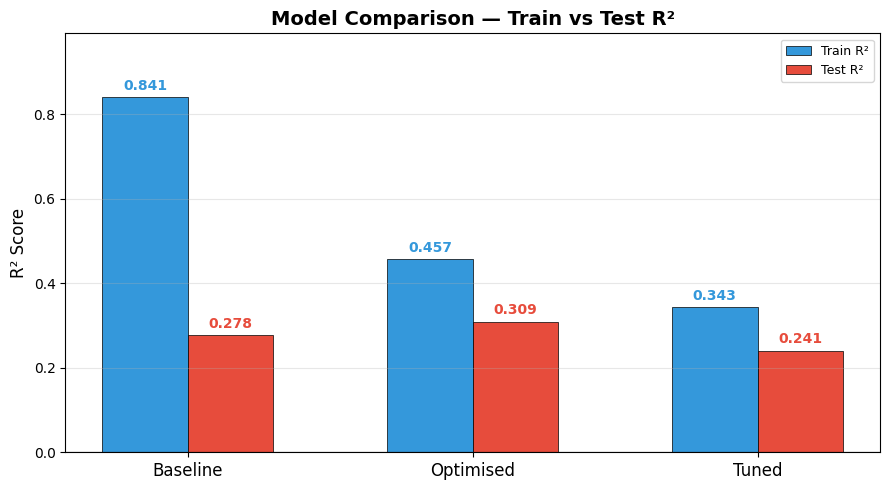

In [9]:
def plot_r2_comparison(eval_results):
    """
    Grouped bar chart comparing Train and Test R² across models.

    Parameters
    ----------
    eval_results : dict
        {model_name: (train_m, test_m, train_pred, test_pred)}
        Direct output from evaluate_model().

    Example
    -------
    ev_base = evaluate_model(baseline_model, dtrain, y_train, dtest, y_test, "Baseline")
    ev_opt  = evaluate_model(opt_model,      dtrain, y_train, dtest, y_test, "Optimised")
    ev_tune = evaluate_model(tuned_model,    dtrain, y_train, dtest, y_test, "Tuned")

    plot_r2_comparison({
        "Baseline":  ev_base,
        "Optimised": ev_opt,
        "Tuned":     ev_tune,
    })
    """
    import matplotlib.pyplot as plt
    import numpy as np

    names    = list(eval_results.keys())
    train_r2 = [v[0]['r2'] for v in eval_results.values()]
    test_r2  = [v[1]['r2'] for v in eval_results.values()]

    x     = np.arange(len(names))
    width = 0.3

    fig, ax = plt.subplots(figsize=(9, 5))

    bars_train = ax.bar(x - width/2, train_r2, width, label='Train R²',
                        color='#3498db', edgecolor='black', linewidth=0.5)
    bars_test  = ax.bar(x + width/2, test_r2,  width, label='Test R²',
                        color='#e74c3c', edgecolor='black', linewidth=0.5)

    for bar in bars_train:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold', color='#3498db')

    for bar in bars_test:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold', color='#e74c3c')

    ax.set_xticks(x)
    ax.set_xticklabels(names, fontsize=12)
    ax.set_ylabel('R² Score', fontsize=12)
    ax.set_title('Model Comparison — Train vs Test R²', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(0, max(train_r2) + 0.15)
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=0, color='black', linewidth=0.8)

    fig.tight_layout()
    plt.show()

plot_r2_comparison({
    "Baseline":  ev_base,
    "Optimised": ev_opt,
    "Tuned":     ev_tune,
})

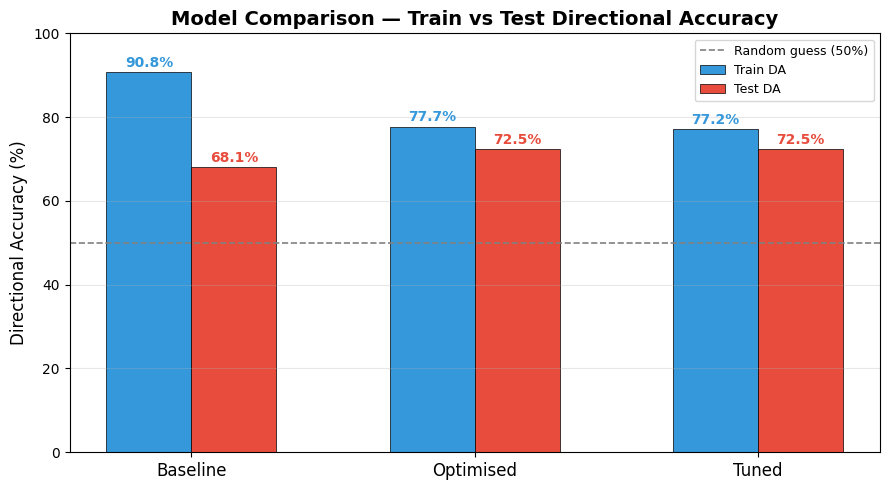

In [10]:
def plot_dir_comparison(eval_results):
    """
    Grouped bar chart comparing Train and Test Directional Accuracy.

    Parameters
    ----------
    eval_results : dict
        {model_name: (train_m, test_m, train_pred, test_pred)}
        Direct output from evaluate_model().
    """
    import matplotlib.pyplot as plt
    import numpy as np

    names     = list(eval_results.keys())
    train_dir = [v[0]['dir'] for v in eval_results.values()]
    test_dir  = [v[1]['dir'] for v in eval_results.values()]

    x     = np.arange(len(names))
    width = 0.3

    fig, ax = plt.subplots(figsize=(9, 5))

    bars_train = ax.bar(x - width/2, train_dir, width, label='Train DA',
                        color='#3498db', edgecolor='black', linewidth=0.5)
    bars_test  = ax.bar(x + width/2, test_dir,  width, label='Test DA',
                        color='#e74c3c', edgecolor='black', linewidth=0.5)

    for bar in bars_train:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', va='bottom',
                fontsize=10, fontweight='bold', color='#3498db')

    for bar in bars_test:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', va='bottom',
                fontsize=10, fontweight='bold', color='#e74c3c')

    # 50% baseline — random guess
    ax.axhline(y=50, color='grey', linestyle='--', linewidth=1.2, label='Random guess (50%)')

    ax.set_xticks(x)
    ax.set_xticklabels(names, fontsize=12)
    ax.set_ylabel('Directional Accuracy (%)', fontsize=12)
    ax.set_title('Model Comparison — Train vs Test Directional Accuracy',
                 fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3, axis='y')

    fig.tight_layout()
    plt.show()


plot_dir_comparison({
    "Baseline":  ev_base,
    "Optimised": ev_opt,
    "Tuned":     ev_tune,
})

In [13]:
# shap_analysis.py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import shap
import xgboost as xgb

# Setup SHAP explainer
print("── Computing SHAP Values ──")

if not isinstance(X_train, pd.DataFrame):
    X_train = pd.DataFrame(X_train, columns=FEATURE_COLS)

if not isinstance(X_test, pd.DataFrame):
    X_test = pd.DataFrame(X_test, columns=FEATURE_COLS)

print(f"  X_train type : {type(X_train)}")
print(f"  X_test  type : {type(X_test)}")

# TreeExplainer is optimised specifically for XGBoost / tree-based modelsr
explainer    = shap.TreeExplainer(model2)

# Compute SHAP values for both train and test
# Shape: (n_samples, n_features)
shap_train   = explainer.shap_values(X_train)
shap_test    = explainer.shap_values(X_test)

# Expected value = baseline prediction (mean of training target)
base_value   = explainer.expected_value
print(f"  Base value (mean prediction) : {base_value:.4f}%")
print(f"  SHAP train matrix shape      : {shap_train.shape}")
print(f"  SHAP test  matrix shape      : {shap_test.shape}")

# SHAP values into DataFrames
shap_train_df = pd.DataFrame(shap_train, columns=FEATURE_COLS)
shap_test_df  = pd.DataFrame(shap_test,  columns=FEATURE_COLS, index=X_test.index)

# Mean absolute SHAP global importance across test set
mean_abs_shap = shap_test_df.abs().mean().sort_values(ascending=False)

print("\nGlobal Feature Importance (Mean |SHAP|) on Test Set")
for feat, val in mean_abs_shap.items():
    bar = '█' * int(val * 20)
    print(f"  {feat:<25} {val:.4f}%  {bar}")




── Computing SHAP Values ──
  X_train type : <class 'pandas.DataFrame'>
  X_test  type : <class 'pandas.DataFrame'>
  Base value (mean prediction) : 0.6384%
  SHAP train matrix shape      : (346, 7)
  SHAP test  matrix shape      : (69, 7)

Global Feature Importance (Mean |SHAP|) on Test Set
  VIX_Change                1.6809%  █████████████████████████████████
  USD_Change                0.2847%  █████
  Rate_Change               0.1676%  ███
  GDP_Growth_lag2           0.1184%  ██
  Credit_Spread_lag2        0.1160%  ██
  Unemp_Change_lag1         0.0880%  █
  CPI_Change_lag1           0.0303%  
